# Receptor Interaction Analysis

This notebook reproduces the receptor knockdown × ligand microenvironment interaction analysis
from the Perturb-Tags spatial multiome data.

## Overview
For each of 8 receptor KD targets, we:
1. Compute a local ligand microenvironment score for each cell using a Gaussian kernel
2. Fit an OLS interaction model: `expression ~ β_KD + β_ligand + β_KD×ligand`
3. Sweep across radii (25-500 µm) to find optimal interaction distances
4. Run the analysis for RNA genes, ATAC peaks, and TE families


In [1]:
# Dependencies were installed before notebook execution.
import sys, subprocess
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'gdown', 'h5py', 'scipy', 'matplotlib', 'pandas', 'numpy', 'statsmodels', 'openpyxl'], check=True)


CompletedProcess(args=['/app/kernel_env/bin/python', '-m', 'pip', 'install', '-q', 'gdown', 'h5py', 'scipy', 'matplotlib', 'pandas', 'numpy', 'statsmodels', 'openpyxl'], returncode=0)

In [2]:
import os
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
from scipy.spatial import KDTree
from scipy.stats import zscore
import statsmodels.api as sm
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = 'data'
OUTPUT_DIR = 'output'
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Google Drive file IDs
DRIVE_IDS = {
    'CATATAC': '1NZzzEX9zHSj5Cp5ewuHRataW0jkIA-bo',
    'TE_RNA': '1PU3dJ0n3siOUqt67knTc3mXWe1k1gROV',
    'TE_ATAC': '1H_7eV_ZynrXNHy0P9YAb66aTWLA9fvIg',
}

CATATAC_PATH = os.path.join(DATA_DIR, 'all_lanes_CATATAC.h5mu')
TE_RNA_PATH = os.path.join(DATA_DIR, 'aggregated_TE_RNA.h5ad')
TE_ATAC_PATH = os.path.join(DATA_DIR, 'aggregated_TE_ATAC.h5ad')

# Receptor-ligand pairs
RECEPTOR_LIGANDS = {
    'FZD3': ['WNT1', 'WNT2', 'WNT2B', 'WNT3', 'WNT3A', 'WNT4', 'WNT5A', 'WNT5B', 'WNT6',
             'WNT7A', 'WNT7B', 'WNT8A', 'WNT8B', 'WNT9A', 'WNT9B', 'WNT10A', 'WNT10B', 'WNT11', 'WNT16'],
    'LGR4': ['RSPO1', 'RSPO2', 'RSPO3', 'RSPO4'],
    'PDGFRA': ['PDGFA', 'PDGFB', 'PDGFC', 'PDGFD'],
    'NRP1': ['SEMA3A', 'SEMA3B', 'SEMA3C', 'SEMA3D', 'SEMA3E', 'SEMA3F', 'SEMA3G',
             'VEGFA', 'VEGFB', 'PGF', 'SEMA6D'],
    'PLXNA2': ['SEMA3A', 'SEMA3B', 'SEMA3C', 'SEMA3D', 'SEMA3F', 'SEMA5A', 'SEMA6A', 'SEMA6B', 'SEMA6D'],
    'EPHA7': ['EFNA1', 'EFNA2', 'EFNA3', 'EFNA4', 'EFNA5'],
    'NOTCH1': ['DLL1', 'DLL3', 'DLL4', 'JAG1', 'JAG2'],
    'ACVR2B': ['BMP2', 'BMP4', 'BMP5', 'BMP6', 'BMP7', 'GDF5', 'GDF11', 'INHBA', 'INHBB', 'NODAL', 'MSTN'],
}

RADII = list(range(25, 525, 25))  # 25, 50, 75, ..., 500
RECEPTOR_TARGETS = list(RECEPTOR_LIGANDS.keys())


## 1. Download data

In [3]:
import gdown

for name, fid in DRIVE_IDS.items():
    path = {'CATATAC': CATATAC_PATH, 'TE_RNA': TE_RNA_PATH, 'TE_ATAC': TE_ATAC_PATH}[name]
    if not os.path.exists(path):
        print(f"Downloading {name}...")
        gdown.download(id=fid, output=path, quiet=False)
    else:
        print(f"{name} already exists at {path}")


CATATAC already exists at data/all_lanes_CATATAC.h5mu
TE_RNA already exists at data/aggregated_TE_RNA.h5ad
TE_ATAC already exists at data/aggregated_TE_ATAC.h5ad


## 2. Load data

In [4]:
def read_categorical(grp):
    # AnnData fields may be categorical groups or plain HDF5 datasets.
    if isinstance(grp, h5py.Dataset):
        return np.array([c.decode() if isinstance(c, bytes) else c for c in grp[:]])
    cats = np.array([c.decode() if isinstance(c, bytes) else c for c in grp['categories'][:]])
    codes = grp['codes'][:]
    return cats[codes]

def read_dataframe_index(grp):
    # AnnData stores the index dataset name in the dataframe group's _index attr.
    key = grp.attrs.get('_index', '_index')
    if isinstance(key, bytes): key = key.decode()
    return read_categorical(grp[key])

def read_nullable_string(grp):
    vals = np.array([c.decode() if isinstance(c, bytes) else c for c in grp['values'][:]])
    if 'mask' in grp:
        mask = grp['mask'][:]
        vals[mask] = ''
    return vals

def read_sparse_matrix(grp):
    from scipy.sparse import csr_matrix, csc_matrix
    data = grp['data'][:]
    indices = grp['indices'][:]
    indptr = grp['indptr'][:]
    shape = tuple(grp.attrs.get('shape', (len(indptr) - 1, indices.max() + 1)))
    encoding = grp.attrs.get('encoding-type', b'csr_matrix')
    if isinstance(encoding, bytes): encoding = encoding.decode()
    if 'csc' in encoding:
        return csc_matrix((data, indices, indptr), shape=shape)
    return csr_matrix((data, indices, indptr), shape=shape)

print("Loading CATATAC multiome data...")
with h5py.File(CATATAC_PATH, 'r') as f:
    target_calls = read_categorical(f['obs']['target_call'])
    lanes = read_categorical(f['obs']['lane'])
    spatial_1 = read_categorical(f['obs']['SPATIAL_1']).astype(float)
    spatial_2 = read_categorical(f['obs']['SPATIAL_2']).astype(float)
    spatial_coords = np.column_stack([spatial_1, spatial_2])
    gex_barcodes = read_categorical(f['obs']['gex_barcode'])

    rna_X = read_sparse_matrix(f['mod']['rna']['X'])
    rna_genes = read_dataframe_index(f['mod']['rna']['var'])

    atac_X = read_sparse_matrix(f['mod']['atac']['X'])
    atac_peaks = read_nullable_string(f['mod']['atac']['var']['peak_id'])

n_cells = len(target_calls)
gene_to_idx = {g: i for i, g in enumerate(rna_genes)}

print(f"Loaded {n_cells} cells, {len(rna_genes)} genes, {len(atac_peaks)} peaks")

# Load TE data
print("Loading TE data...")
with h5py.File(TE_RNA_PATH, 'r') as f:
    te_rna_barcodes = np.array([c.decode() if isinstance(c, bytes) else c for c in f['obs']['barcode'][:]])
    te_rna_lanes = np.array([c.decode() if isinstance(c, bytes) else c for c in f['obs']['lane'][:]])
    te_rna_X = read_sparse_matrix(f['X'])
    te_rna_names = read_dataframe_index(f['var'])

with h5py.File(TE_ATAC_PATH, 'r') as f:
    te_atac_barcodes = np.array([c.decode() if isinstance(c, bytes) else c for c in f['obs']['barcode'][:]])
    te_atac_lanes = np.array([c.decode() if isinstance(c, bytes) else c for c in f['obs']['lane'][:]])
    te_atac_X = read_sparse_matrix(f['X'])
    te_atac_names = read_dataframe_index(f['var'])

# Build barcode maps for TE data
catatac_keys = np.array([f"{lane}_{bc}" for lane, bc in zip(lanes, gex_barcodes)])
te_rna_key_to_idx = {f"{l}_{b}": i for i, (l, b) in enumerate(zip(te_rna_lanes, te_rna_barcodes))}
te_atac_key_to_idx = {f"{l}_{b}": i for i, (l, b) in enumerate(zip(te_atac_lanes, te_atac_barcodes))}
te_rna_idx_map = np.array([te_rna_key_to_idx.get(k, -1) for k in catatac_keys])
te_atac_idx_map = np.array([te_atac_key_to_idx.get(k, -1) for k in catatac_keys])

print(f"TE RNA: {te_rna_X.shape}, TE ATAC: {te_atac_X.shape}")


Loading CATATAC multiome data...


Loaded 17043 cells, 29562 genes, 142529 peaks
Loading TE data...


TE RNA: (17043, 1340), TE ATAC: (42680, 1391)


## 3. Compute ligand microenvironment scores

In [5]:
def compute_ligand_score(cell_indices, spatial_coords, rna_X, gene_to_idx, 
                         ligand_genes, radius, lanes, lane_values,
                         exclude_kd_indices=None):
    """Compute Gaussian-weighted ligand score for each cell.

    For each cell, find neighbors within radius in the same lane (EB).
    Weight neighbors by Gaussian kernel: w(d) = exp(-d^2 / (2*sigma^2))
    where sigma = radius / sqrt(-2*log(0.001)).
    Compute weighted mean of total ligand expression across neighbors.
    """
    sigma = radius / np.sqrt(-2 * np.log(0.001))

    # Find ligand gene indices that exist in the data
    ligand_idxs = [gene_to_idx[g] for g in ligand_genes if g in gene_to_idx]
    if not ligand_idxs:
        return np.zeros(len(cell_indices))

    # Precompute total ligand expression per cell
    ligand_expr = np.array(rna_X[:, ligand_idxs].sum(axis=1)).ravel()

    scores = np.zeros(len(cell_indices))
    exclude_set = set(exclude_kd_indices) if exclude_kd_indices is not None else set()

    for lane in lane_values:
        lane_mask = lanes == lane
        lane_cell_idxs = np.where(lane_mask)[0]

        # Build KDTree for this lane
        lane_coords = spatial_coords[lane_cell_idxs]
        tree = KDTree(lane_coords)

        # Map cell_indices to positions in this lane
        lane_set = set(lane_cell_idxs)

        for i, cell_idx in enumerate(cell_indices):
            if cell_idx not in lane_set:
                continue

            # Find position in lane arrays
            cell_pos = np.searchsorted(lane_cell_idxs, cell_idx)
            if cell_pos >= len(lane_cell_idxs) or lane_cell_idxs[cell_pos] != cell_idx:
                continue

            # Query neighbors
            neighbor_positions = tree.query_ball_point(lane_coords[cell_pos], radius)

            # Get global indices, exclude self and KD cells
            neighbor_global = [lane_cell_idxs[p] for p in neighbor_positions 
                             if lane_cell_idxs[p] != cell_idx and lane_cell_idxs[p] not in exclude_set]

            if not neighbor_global:
                continue

            # Gaussian weights
            dists = np.linalg.norm(spatial_coords[neighbor_global] - spatial_coords[cell_idx], axis=1)
            weights = np.exp(-dists**2 / (2 * sigma**2))
            weights /= weights.sum()

            # Weighted ligand score
            scores[i] = np.dot(weights, ligand_expr[neighbor_global])

    return scores


## 4. Interaction regression

In [6]:
def run_interaction_regression(kd_indices, ctrl_indices, ligand_scores_kd, ligand_scores_ctrl,
                               expression_matrix, feature_names, min_det=0.05):
    """Run OLS expression ~ KD + ligand + KD*ligand, vectorized across features."""
    from scipy.stats import t as student_t
    from statsmodels.stats.multitest import multipletests
    from scipy import sparse

    all_indices = np.concatenate([kd_indices, ctrl_indices])
    n_kd, n_ctrl = len(kd_indices), len(ctrl_indices)
    kd_var = np.concatenate([np.ones(n_kd), np.zeros(n_ctrl)])
    all_ligand = np.concatenate([ligand_scores_kd, ligand_scores_ctrl])
    if all_ligand.std() <= 0:
        return pd.DataFrame()
    all_ligand_z = zscore(all_ligand)
    X = np.column_stack([np.ones(len(all_indices)), kd_var, all_ligand_z, kd_var * all_ligand_z])
    rank = np.linalg.matrix_rank(X)
    if rank < X.shape[1]:
        return pd.DataFrame()

    Y = expression_matrix[all_indices, :]
    if sparse.issparse(Y):
        Y = Y.tocsr()
        detected = np.asarray((Y != 0).mean(axis=0)).ravel()
    else:
        Y = np.asarray(Y)
        detected = (Y != 0).mean(axis=0)
    keep = detected >= min_det
    if not np.any(keep):
        return pd.DataFrame()
    Y = Y[:, keep]
    names = np.asarray(feature_names)[keep]

    xtx_inv = np.linalg.inv(X.T @ X)
    xty = np.asarray(X.T @ Y)
    beta = xtx_inv @ xty
    if sparse.issparse(Y):
        yty = np.asarray(Y.multiply(Y).sum(axis=0)).ravel()
    else:
        yty = np.einsum('ij,ij->j', Y, Y)
    sse = np.maximum(yty - np.einsum('ij,ij->j', beta, xty), 0)
    df_resid = len(all_indices) - rank
    sigma2 = sse / df_resid
    se = np.sqrt(np.maximum(np.diag(xtx_inv)[:, None] * sigma2[None, :], 0))
    with np.errstate(divide='ignore', invalid='ignore'):
        tvals = beta / se
    pvals = 2 * student_t.sf(np.abs(tvals), df_resid)
    pvals = np.nan_to_num(pvals, nan=1.0, posinf=0.0, neginf=0.0)

    df = pd.DataFrame({
        'gene': names,
        'beta_KD': beta[1], 'beta_ligand': beta[2], 'beta_interaction': beta[3],
        'p_KD': pvals[1], 'p_ligand': pvals[2], 'p_interaction': pvals[3],
    })
    for col in ['p_KD', 'p_ligand', 'p_interaction']:
        df[col.replace('p_', 'fdr_')] = multipletests(df[col], method='fdr_bh')[1]
    return df.sort_values('p_interaction')


In [7]:
# Run interaction analysis across all receptors and radii
excluded = {'Unassigned', 'No_CRISPR_data'}
ntc_mask = target_calls == 'Non-Targeting'
lane_values = np.unique(lanes)

# Use a subset of radii for the sweep (every 25 µm from 25 to 500)
SWEEP_RADII = list(range(25, 525, 25))

summary_rows = []
all_receptor_results = {}

for receptor in RECEPTOR_TARGETS:
    print(f"\n{'='*60}")
    print(f"Processing {receptor}...")

    kd_mask = target_calls == receptor
    kd_indices = np.where(kd_mask)[0]
    ctrl_indices = np.where(ntc_mask)[0]

    if len(kd_indices) < 20:
        print(f"  Skipping: only {len(kd_indices)} KD cells")
        continue

    ligands = RECEPTOR_LIGANDS[receptor]
    print(f"  KD cells: {len(kd_indices)}, NTC cells: {len(ctrl_indices)}")
    print(f"  Ligands: {ligands}")

    receptor_results = {}

    for radius in SWEEP_RADII:
        print(f"  Radius {radius} µm...", end=' ')

        # Compute ligand scores
        all_test_indices = np.concatenate([kd_indices, ctrl_indices])
        other_kd = np.where(np.isin(target_calls, list(RECEPTOR_LIGANDS.keys())) & ~kd_mask & ~ntc_mask)[0]

        ligand_scores = compute_ligand_score(
            all_test_indices, spatial_coords, rna_X, gene_to_idx,
            ligands, radius, lanes, lane_values,
            exclude_kd_indices=set(kd_indices.tolist()) | set(other_kd.tolist())
        )

        ligand_kd = ligand_scores[:len(kd_indices)]
        ligand_ctrl = ligand_scores[len(kd_indices):]

        # RNA interaction
        rna_df = run_interaction_regression(kd_indices, ctrl_indices, ligand_kd, ligand_ctrl,
                                            rna_X, rna_genes, min_det=0.05)

        # ATAC interaction
        atac_df = run_interaction_regression(kd_indices, ctrl_indices, ligand_kd, ligand_ctrl,
                                             atac_X, atac_peaks, min_det=0.01)

        # TE RNA interaction
        te_rna_kd = te_rna_idx_map[kd_indices]
        te_rna_ctrl = te_rna_idx_map[ctrl_indices]
        te_rna_valid_kd = te_rna_kd[te_rna_kd >= 0]
        te_rna_valid_ctrl = te_rna_ctrl[te_rna_ctrl >= 0]

        if len(te_rna_valid_kd) > 10 and len(te_rna_valid_ctrl) > 10:
            te_rna_df = run_interaction_regression(
                te_rna_valid_kd, te_rna_valid_ctrl,
                ligand_kd[te_rna_kd >= 0], ligand_ctrl[te_rna_ctrl >= 0],
                te_rna_X, te_rna_names, min_det=0.05)
        else:
            te_rna_df = pd.DataFrame()

        # TE ATAC interaction
        te_atac_kd = te_atac_idx_map[kd_indices]
        te_atac_ctrl = te_atac_idx_map[ctrl_indices]
        te_atac_valid_kd = te_atac_kd[te_atac_kd >= 0]
        te_atac_valid_ctrl = te_atac_ctrl[te_atac_ctrl >= 0]

        if len(te_atac_valid_kd) > 10 and len(te_atac_valid_ctrl) > 10:
            te_atac_df = run_interaction_regression(
                te_atac_valid_kd, te_atac_valid_ctrl,
                ligand_kd[te_atac_kd >= 0], ligand_ctrl[te_atac_ctrl >= 0],
                te_atac_X, te_atac_names, min_det=0.01)
        else:
            te_atac_df = pd.DataFrame()

        # Count significant hits
        n_rna_kd = (rna_df['fdr_KD'] < 0.05).sum() if len(rna_df) > 0 else 0
        n_rna_lig = (rna_df['fdr_ligand'] < 0.05).sum() if len(rna_df) > 0 else 0
        n_rna_int = (rna_df['fdr_interaction'] < 0.05).sum() if len(rna_df) > 0 else 0
        n_atac_kd = (atac_df['fdr_KD'] < 0.05).sum() if len(atac_df) > 0 else 0
        n_atac_lig = (atac_df['fdr_ligand'] < 0.05).sum() if len(atac_df) > 0 else 0
        n_atac_int = (atac_df['fdr_interaction'] < 0.05).sum() if len(atac_df) > 0 else 0
        n_te_rna_int = (te_rna_df['fdr_interaction'] < 0.05).sum() if len(te_rna_df) > 0 else 0
        n_te_atac_int = (te_atac_df['fdr_interaction'] < 0.05).sum() if len(te_atac_df) > 0 else 0

        print(f"RNA: KD={n_rna_kd}, lig={n_rna_lig}, int={n_rna_int}; "
              f"ATAC: KD={n_atac_kd}, lig={n_atac_lig}, int={n_atac_int}; "
              f"TE RNA int={n_te_rna_int}, TE ATAC int={n_te_atac_int}")

        summary_rows.append({
            'Receptor': receptor, 'Radius': radius,
            'RNA_KD': n_rna_kd, 'RNA_ligand': n_rna_lig, 'RNA_interaction': n_rna_int,
            'ATAC_KD': n_atac_kd, 'ATAC_ligand': n_atac_lig, 'ATAC_interaction': n_atac_int,
            'TE_RNA_interaction': n_te_rna_int, 'TE_ATAC_interaction': n_te_atac_int,
        })

        receptor_results[radius] = {
            'rna': rna_df, 'atac': atac_df, 
            'te_rna': te_rna_df, 'te_atac': te_atac_df,
        }

    all_receptor_results[receptor] = receptor_results

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(os.path.join(OUTPUT_DIR, 'receptor_interaction_summary.csv'), index=False)
print("\nSummary saved.")



Processing FZD3...
  KD cells: 265, NTC cells: 581
  Ligands: ['WNT1', 'WNT2', 'WNT2B', 'WNT3', 'WNT3A', 'WNT4', 'WNT5A', 'WNT5B', 'WNT6', 'WNT7A', 'WNT7B', 'WNT8A', 'WNT8B', 'WNT9A', 'WNT9B', 'WNT10A', 'WNT10B', 'WNT11', 'WNT16']
  Radius 25 µm... 

RNA: KD=1, lig=21, int=0; ATAC: KD=0, lig=194, int=51; TE RNA int=0, TE ATAC int=0
  Radius 50 µm... 

RNA: KD=1, lig=78, int=0; ATAC: KD=0, lig=17, int=5; TE RNA int=0, TE ATAC int=0
  Radius 75 µm... 

RNA: KD=2, lig=77, int=0; ATAC: KD=0, lig=14, int=2; TE RNA int=0, TE ATAC int=0
  Radius 100 µm... 

RNA: KD=1, lig=74, int=0; ATAC: KD=0, lig=9, int=4; TE RNA int=0, TE ATAC int=0
  Radius 125 µm... 

...

RNA: KD=692, lig=99, int=0; ATAC: KD=35, lig=20, int=3; TE RNA int=0, TE ATAC int=0
  Radius 425 µm... 

RNA: KD=693, lig=99, int=0; ATAC: KD=36, lig=19, int=3; TE RNA int=0, TE ATAC int=0
  Radius 450 µm... 

RNA: KD=693, lig=102, int=0; ATAC: KD=36, lig=17, int=2; TE RNA int=0, TE ATAC int=0
  Radius 475 µm... 

RNA: KD=693, lig=104, int=0; ATAC: KD=36, lig=18, int=2; TE RNA int=0, TE ATAC int=0
  Radius 500 µm... 

RNA: KD=693, lig=106, int=0; ATAC: KD=36, lig=17, int=2; TE RNA int=0, TE ATAC int=0

Summary saved.


## 5. Radius sweep heatmap

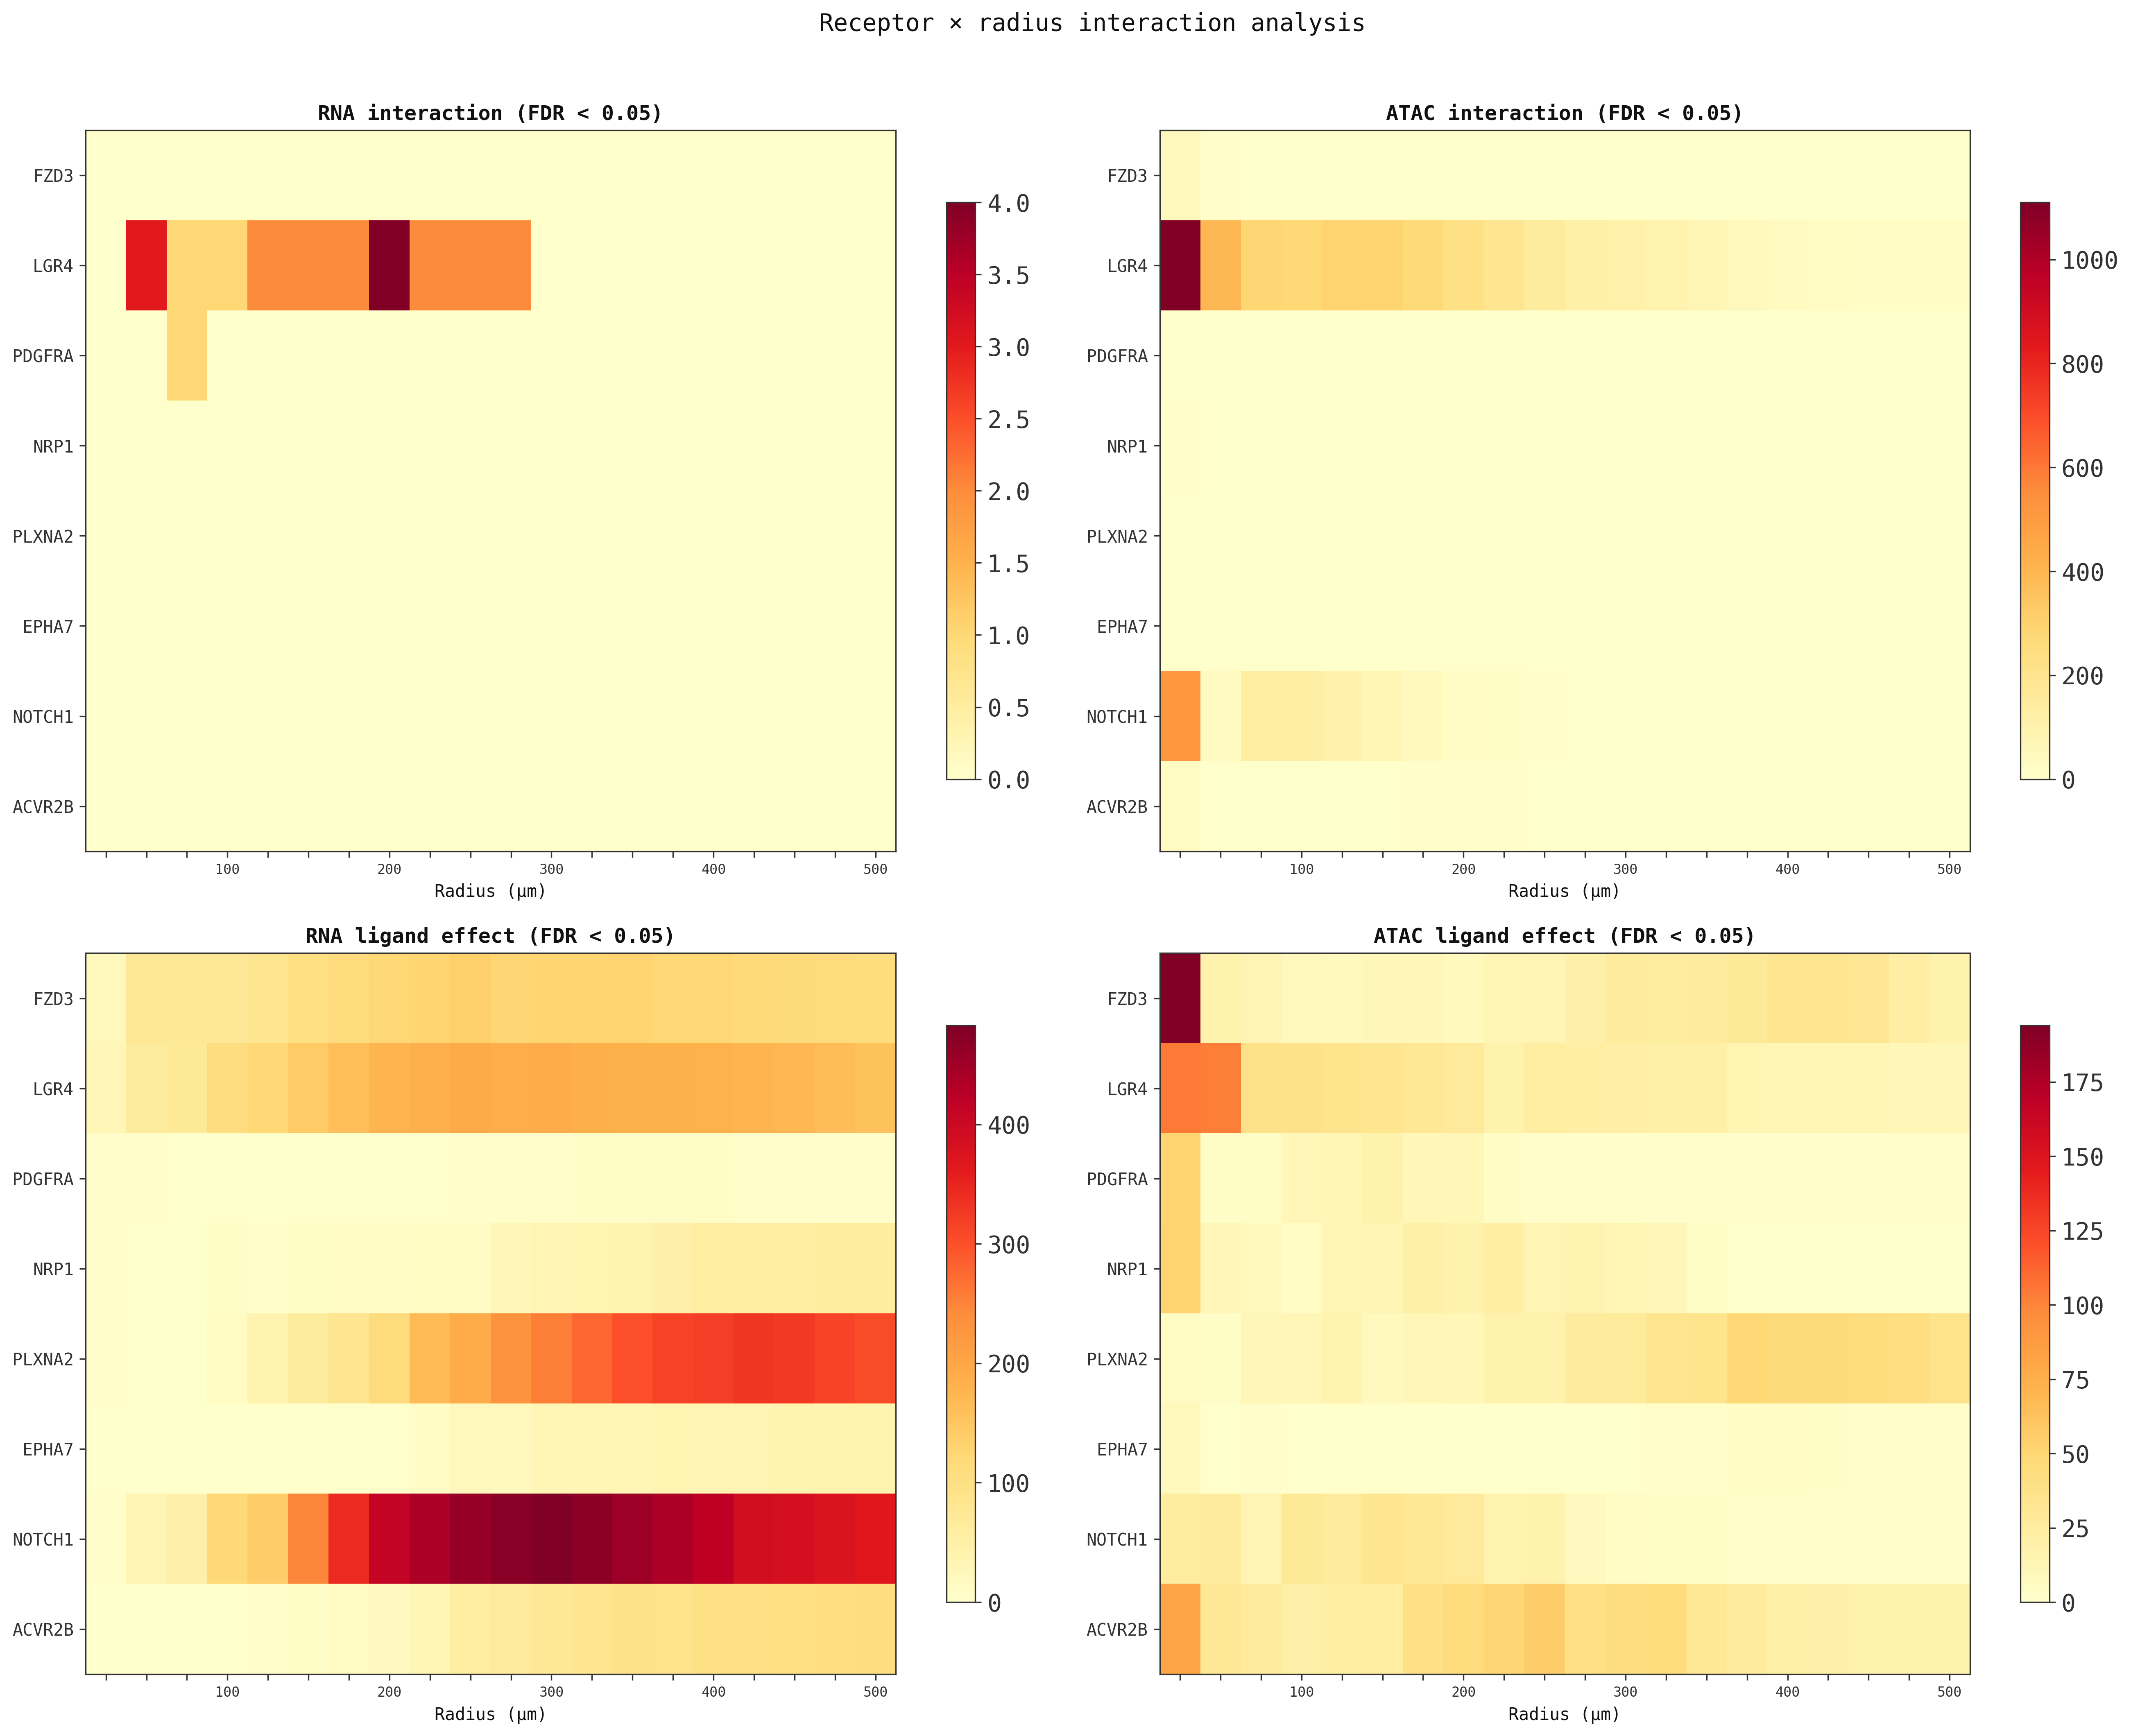

In [8]:
# Interaction radius heatmap
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

for ax_idx, (col, title) in enumerate([
    ('RNA_interaction', 'RNA interaction (FDR < 0.05)'),
    ('ATAC_interaction', 'ATAC interaction (FDR < 0.05)'),
    ('RNA_ligand', 'RNA ligand effect (FDR < 0.05)'),
    ('ATAC_ligand', 'ATAC ligand effect (FDR < 0.05)'),
]):
    ax = axes[ax_idx // 2, ax_idx % 2]

    pivot = summary_df.pivot(index='Receptor', columns='Radius', values=col)
    pivot = pivot.reindex(RECEPTOR_TARGETS)

    im = ax.imshow(pivot.values, aspect='auto', cmap='YlOrRd', interpolation='nearest')
    ax.set_xticks(range(len(SWEEP_RADII)))
    ax.set_xticklabels([str(r) if r % 100 == 0 else '' for r in SWEEP_RADII], fontsize=8)
    ax.set_yticks(range(len(RECEPTOR_TARGETS)))
    ax.set_yticklabels(RECEPTOR_TARGETS, fontsize=10)
    ax.set_xlabel('Radius (µm)', fontsize=10)
    ax.set_title(title, fontsize=12, fontweight='bold')
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle('Receptor × radius interaction analysis', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'interaction_radius_heatmap.png'), dpi=200, bbox_inches='tight')
plt.show()


## 6. Interaction coefficient line plots

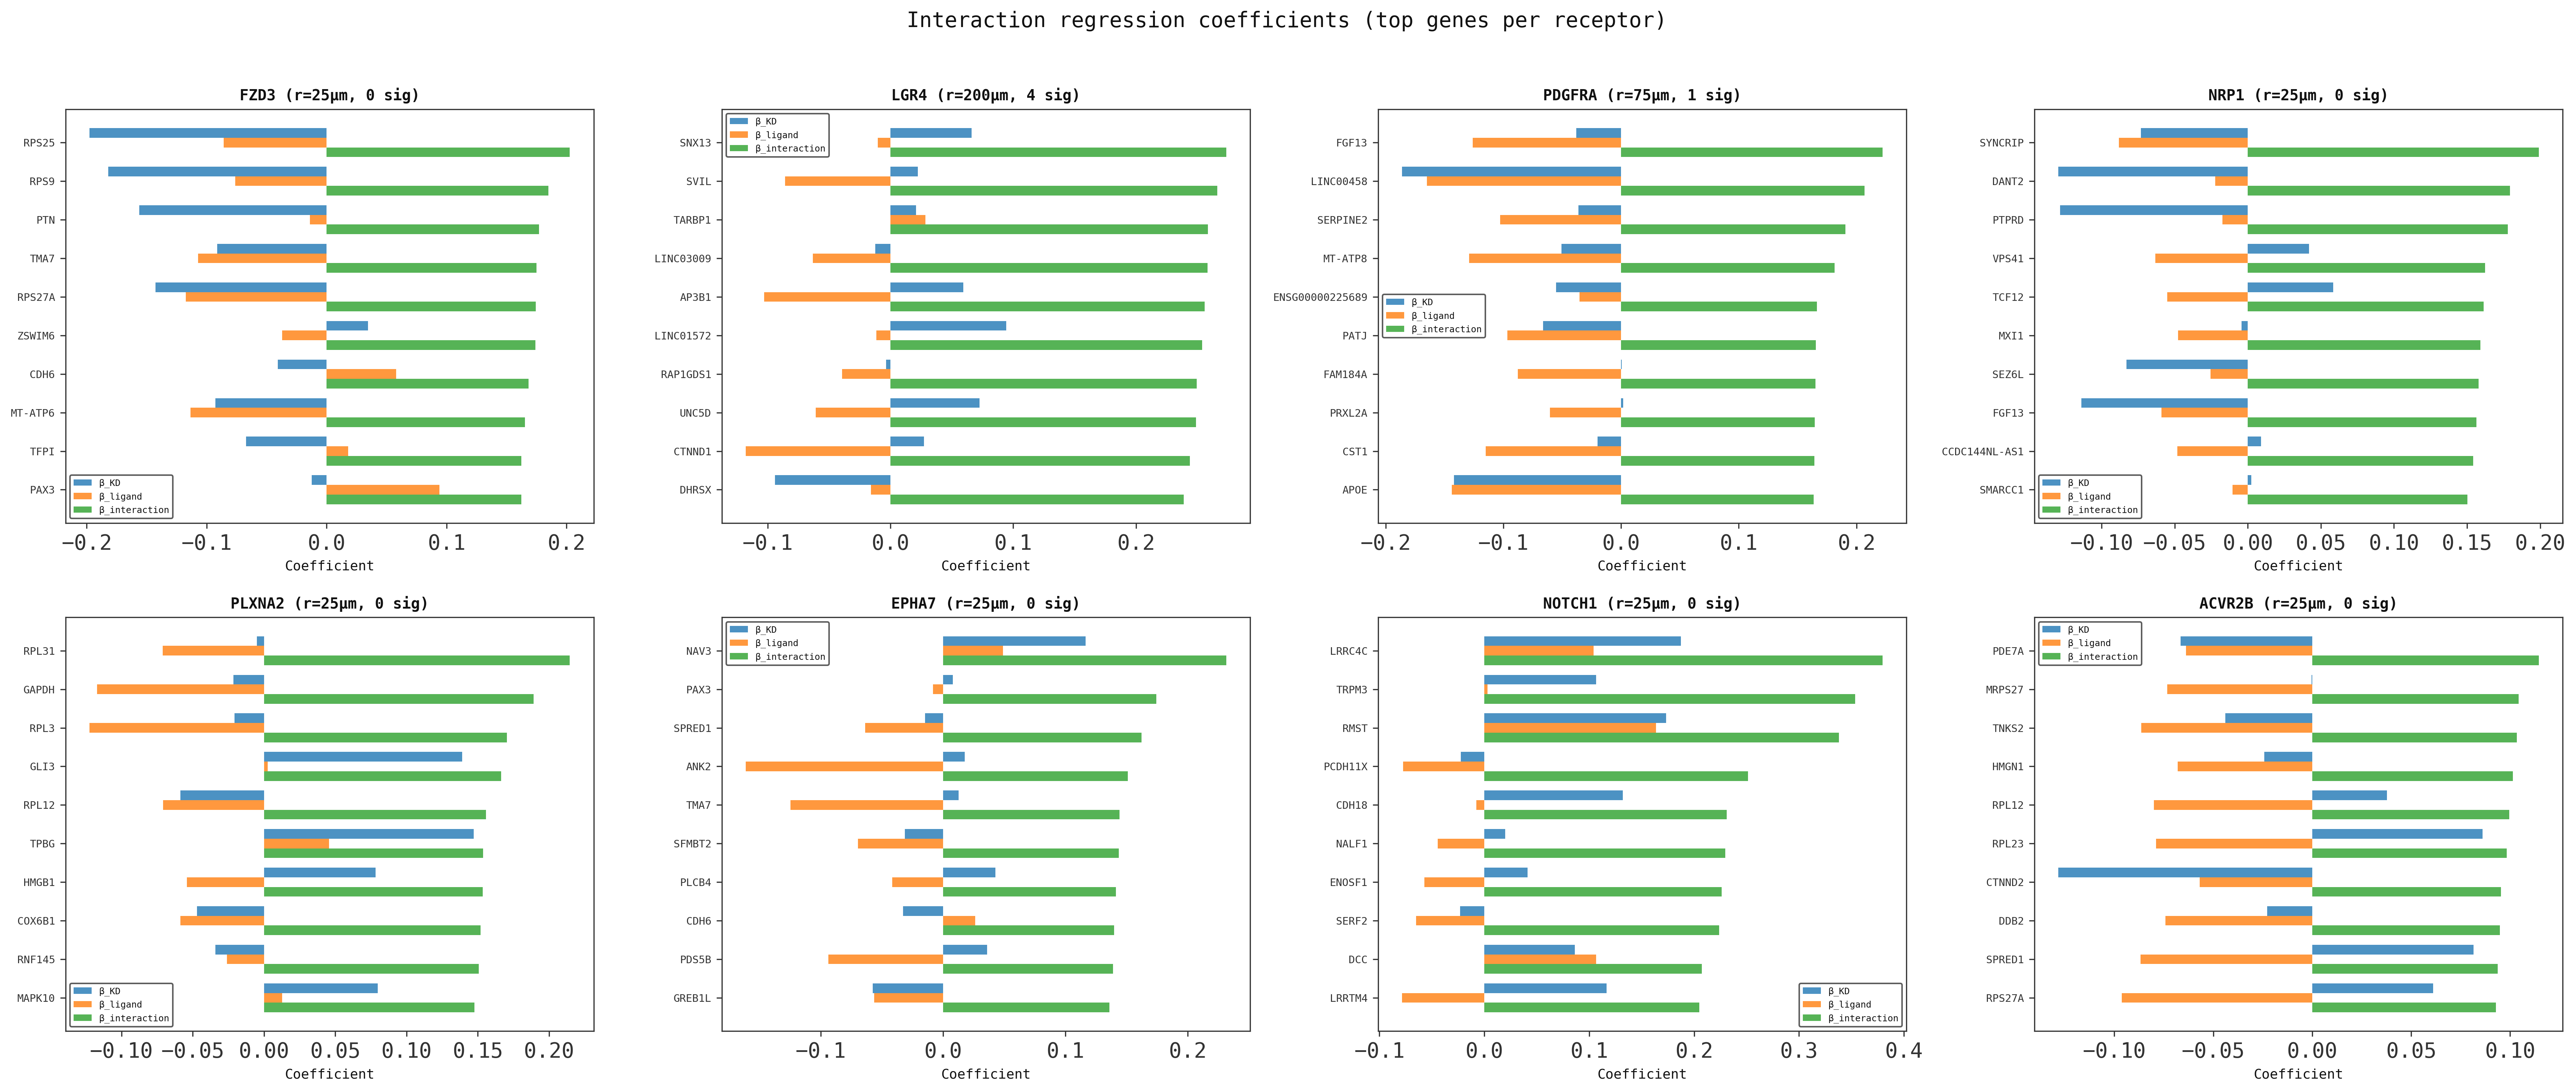

In [9]:
# Line plots showing β_KD, β_ligand, β_interaction for top genes per receptor
fig, axes = plt.subplots(2, 4, figsize=(24, 10))

for r_idx, receptor in enumerate(RECEPTOR_TARGETS):
    ax = axes[r_idx // 4, r_idx % 4]

    if receptor not in all_receptor_results:
        ax.set_title(f'{receptor} (no data)')
        continue

    # Find the best radius (most interaction hits)
    best_radius = max(all_receptor_results[receptor].keys(),
                     key=lambda r: len(all_receptor_results[receptor][r]['rna'].query('fdr_interaction < 0.05'))
                     if len(all_receptor_results[receptor][r]['rna']) > 0 else 0)

    best_df = all_receptor_results[receptor][best_radius]['rna']
    if len(best_df) == 0:
        ax.set_title(f'{receptor} (no RNA results)')
        continue

    # Plot top 10 by |beta_interaction|
    top = best_df.nlargest(10, 'beta_interaction', keep='first')

    x = np.arange(len(top))
    w = 0.25
    ax.barh(x - w, top['beta_KD'], height=w, color='#1f77b4', alpha=0.8, label='β_KD')
    ax.barh(x, top['beta_ligand'], height=w, color='#ff7f0e', alpha=0.8, label='β_ligand')
    ax.barh(x + w, top['beta_interaction'], height=w, color='#2ca02c', alpha=0.8, label='β_interaction')

    ax.set_yticks(x)
    ax.set_yticklabels(top['gene'], fontsize=7)
    ax.set_xlabel('Coefficient', fontsize=9)
    n_sig = (best_df['fdr_interaction'] < 0.05).sum()
    ax.set_title(f'{receptor} (r={best_radius}µm, {n_sig} sig)', fontsize=10, fontweight='bold')
    ax.legend(fontsize=6)
    ax.invert_yaxis()

plt.suptitle('Interaction regression coefficients (top genes per receptor)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'interaction_coefficients.png'), dpi=200, bbox_inches='tight')
plt.show()


## 7. TE interaction results

Total significant TE interactions: 51
Receptor     TE_name Modality  Radius  beta_interaction      FDR
    FZD3 L1PA14_5end   TE_RNA     200          0.000028 0.043779
    FZD3 L1PA14_5end   TE_RNA     225          0.000030 0.018740
    FZD3 L1PA14_5end   TE_RNA     250          0.000031 0.010583
    FZD3 L1PA14_5end   TE_RNA     275          0.000031 0.007263
    FZD3 L1PA14_5end   TE_RNA     300          0.000032 0.005741
    FZD3 L1PA14_5end   TE_RNA     325          0.000032 0.004961
    FZD3 L1PA14_5end   TE_RNA     350          0.000032 0.004612
    FZD3 L1PA14_5end   TE_RNA     375          0.000032 0.004584
    FZD3 L1PA14_5end   TE_RNA     400          0.000032 0.004808
    FZD3 L1PA14_5end   TE_RNA     425          0.000032 0.005360
    FZD3 L1PA14_5end   TE_RNA     450          0.000032 0.006331
    FZD3 L1PA14_5end   TE_RNA     475          0.000032 0.007790
    FZD3 L1PA14_5end   TE_RNA     500          0.000031 0.010030
    LGR4        MER2   TE_RNA     175          0.000

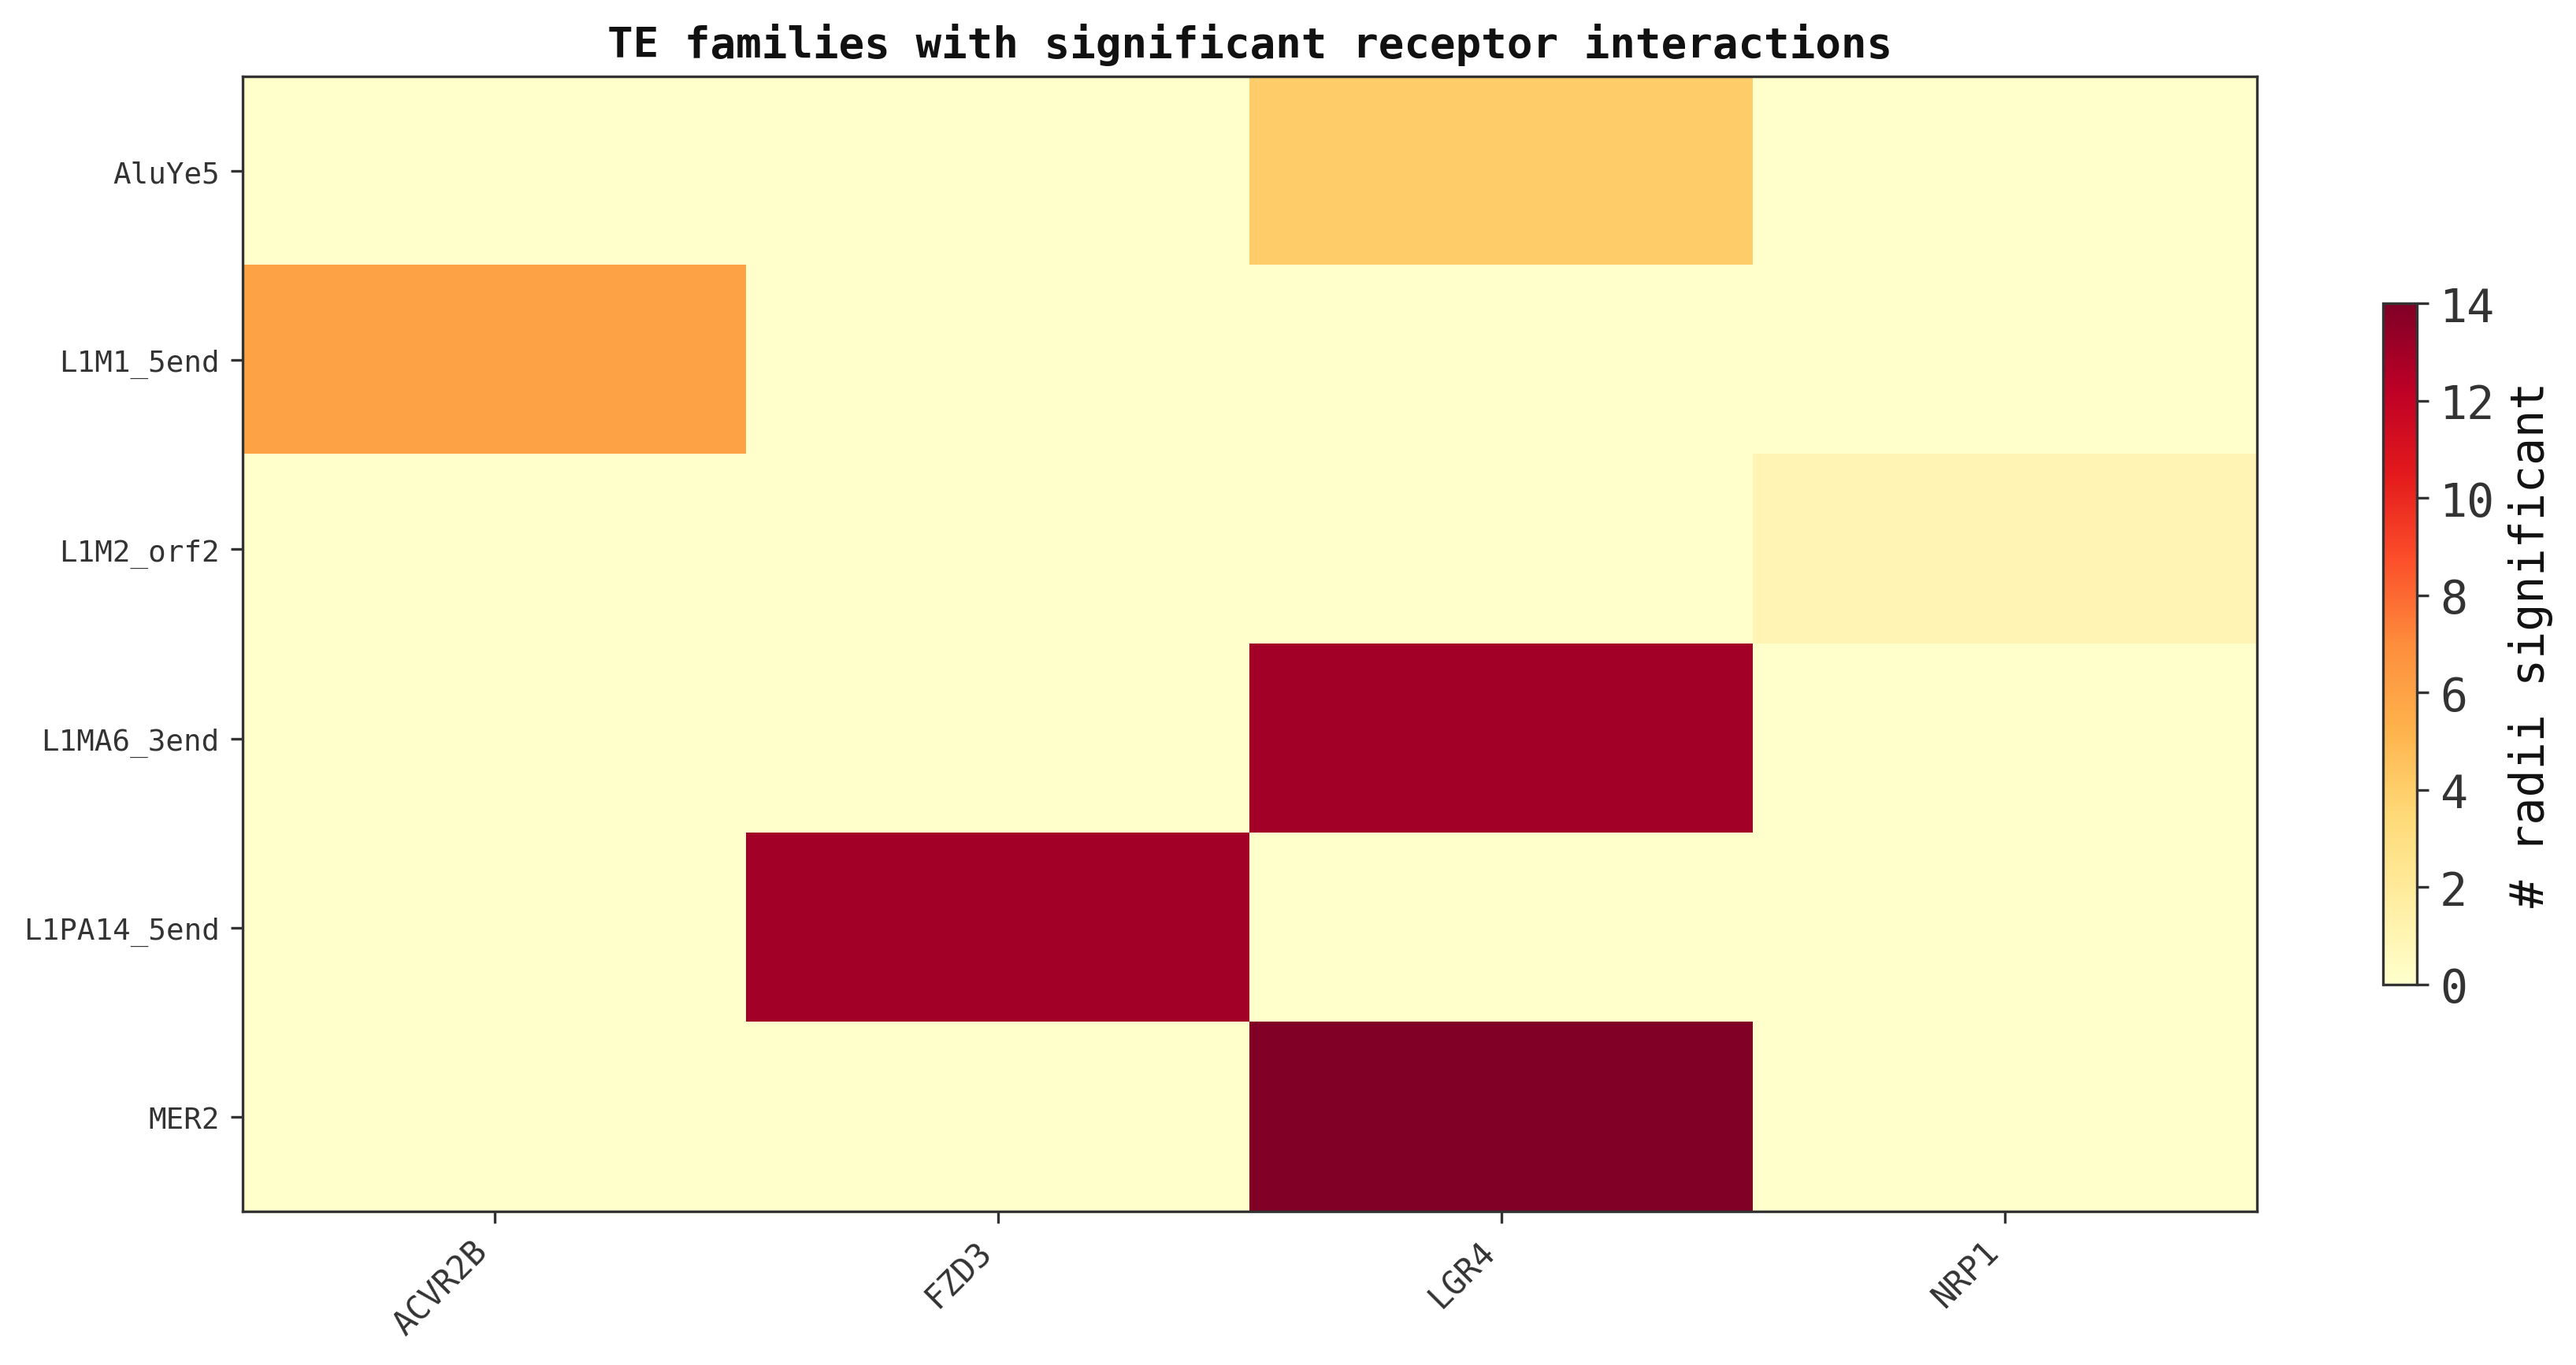

In [10]:
# Collect significant TE interactions across all receptors and radii
te_interaction_results = []

for receptor in RECEPTOR_TARGETS:
    if receptor not in all_receptor_results:
        continue
    for radius, results in all_receptor_results[receptor].items():
        for modality, df in [('TE_RNA', results.get('te_rna', pd.DataFrame())),
                             ('TE_ATAC', results.get('te_atac', pd.DataFrame()))]:
            if len(df) == 0:
                continue
            sig = df[df['fdr_interaction'] < 0.05]
            for _, row in sig.iterrows():
                te_interaction_results.append({
                    'Receptor': receptor,
                    'TE_name': row['gene'],
                    'Modality': modality,
                    'Radius': radius,
                    'beta_interaction': row['beta_interaction'],
                    'FDR': row['fdr_interaction'],
                })

if te_interaction_results:
    te_int_df = pd.DataFrame(te_interaction_results)
    print(f"Total significant TE interactions: {len(te_int_df)}")
    print(te_int_df.to_string(index=False))

    # Heatmap: receptors × TE families
    te_counts = te_int_df.groupby(['Receptor', 'TE_name']).size().reset_index(name='n_radii')

    if len(te_counts) > 0:
        te_pivot = te_counts.pivot(index='TE_name', columns='Receptor', values='n_radii').fillna(0)

        fig, ax = plt.subplots(figsize=(12, max(6, len(te_pivot) * 0.4)))
        im = ax.imshow(te_pivot.values, aspect='auto', cmap='YlOrRd', interpolation='nearest')
        ax.set_xticks(range(len(te_pivot.columns)))
        ax.set_xticklabels(te_pivot.columns, rotation=45, ha='right', fontsize=10)
        ax.set_yticks(range(len(te_pivot.index)))
        ax.set_yticklabels(te_pivot.index, fontsize=9)
        ax.set_title('TE families with significant receptor interactions', fontsize=13, fontweight='bold')
        plt.colorbar(im, ax=ax, label='# radii significant', shrink=0.6)
        plt.tight_layout()
        plt.savefig(os.path.join(OUTPUT_DIR, 'TE_interaction_heatmap.png'), dpi=200, bbox_inches='tight')
        plt.show()
else:
    print("No significant TE interactions found.")


In [11]:
# Save full results to Excel
with pd.ExcelWriter(os.path.join(OUTPUT_DIR, 'receptor_interaction_results.xlsx'), engine='openpyxl') as writer:
    summary_df.to_excel(writer, sheet_name='Summary', index=False)

    # Per-receptor RNA results at best radius
    for receptor in RECEPTOR_TARGETS:
        if receptor not in all_receptor_results:
            continue
        best_radius = max(all_receptor_results[receptor].keys(),
                         key=lambda r: len(all_receptor_results[receptor][r]['rna'].query('fdr_interaction < 0.05'))
                         if len(all_receptor_results[receptor][r]['rna']) > 0 else 0)
        rna_df = all_receptor_results[receptor][best_radius]['rna']
        if len(rna_df) > 0:
            rna_df.to_excel(writer, sheet_name=f'{receptor}_RNA', index=False)

    # TE interactions
    if te_interaction_results:
        te_int_df.to_excel(writer, sheet_name='TE_interactions', index=False)

print(f"\nResults saved to {OUTPUT_DIR}/receptor_interaction_results.xlsx")
print(f"All figures saved to {OUTPUT_DIR}/")



Results saved to output/receptor_interaction_results.xlsx
All figures saved to output/
